In [1]:
pip install polars

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Error correction model (EC) used for only 2 timeseries but
# VECTOR Error Correction model (VEC) used for more than 2 timeseries
#VEC and VAR(p) are rekated to each other only difference is VEC have ERROR CORRECTION TERM.

In [3]:
import pandas as pd
import polars as pl
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
import matplotlib.pyplot as plt


class TimeSeriesDataLoader:
    """Flexible data loader supporting yfinance, CSVs, and tick/intraday aggregation."""

    def __init__(self):
        self.series_dict = {}

    def add_from_yfinance(
        self, ticker: str, name: str, period: str = "7d", interval: str = "1m"
    ) -> "TimeSeriesDataLoader":
        """Fetch high-frequency or daily data from yfinance.

        Intervals: '1m', '2m', '5m', '15m', '60m', '1d', etc.
        """
        data = yf.download(ticker, period=period, interval=interval, progress=False)

        # Extract Close price and handle MultiIndex if returned by yfinance
        if isinstance(data.columns, pd.MultiIndex):
            s = data["Close"][ticker]
        else:
            s = data["Close"]

        s.name = name
        s.index = pd.to_datetime(s.index)
        self.series_dict[name] = s
        return self

    def add_from_csv(
        self,
        filepath: str,
        name: str,
        date_col: str,
        val_col: str,
        resample_freq: str = None,
    ) -> "TimeSeriesDataLoader":
        """Fast load from CSV using Polars, with optional downsampling for ticks."""
        # Use Polars for ultra-fast reading
        p_df = pl.read_csv(filepath)

        # Convert to pandas for statsmodels compatibility
        df = p_df.select([date_col, val_col]).to_pandas()
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col).sort_index()

        # Resample tick data to uniform intervals (e.g., '1s', '1min', '5min')
        if resample_freq:
            s = df[val_col].resample(resample_freq).last().ffill()
        else:
            s = df[val_col]

        s.name = name
        self.series_dict[name] = s
        return self

    def build_dataset(self, resample_freq: str = "1min") -> pd.DataFrame:
        """Aligns all added time series into a single clean DataFrame."""
        if not self.series_dict:
            raise ValueError("No time series added!")

        # Combine all series along index and forward-fill missing high-frequency timestamps
        df = pd.concat(self.series_dict.values(), axis=1)

        # Standardize grid frequency across all assets (ideal for 1m / 5m data)
        if resample_freq:
            df = df.resample(resample_freq).last()

        # Clean missing values resulting from non-overlapping market hours
        df = df.ffill().bfill().dropna()
        return df


# --- EXAMPLE USAGE ---
loader = TimeSeriesDataLoader()

# Add N time-series from yfinance (e.g., 1-minute intraday data)
loader.add_from_yfinance("AUDUSD=X", name="AUDUSD", period="5y", interval="1d")
loader.add_from_yfinance("NZDUSD=X", name="NZDUSD", period="5y", interval="1d")
loader.add_from_yfinance("CAD=X", name="USDCAD", period="5y", interval="1d")
#loader.add_from_yfinance("N", name="N", period="N", interval="N")

# Add N time-series from CSV files (e.g., tick or intraday file)
# loader.add_from_csv('tick_data.csv', name='CADUSD', date_col='Timestamp', val_col='Price', resample_freq='1min')

# Build combined dataset aligned to 1-minute grid
data = loader.build_dataset(resample_freq="1d")

# Invert USDCAD if present to match USD valuation
if "USDCAD" in data.columns:
    data["CADUSD"] = 1 / data["USDCAD"]
    data = data.drop(columns=["USDCAD"])

print(f"Data shape loaded: {data.shape}")
data.head()

C:\Users\Pandya Anand\AppData\Local\Temp\ipykernel_28184\4053356346.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval=interval, progress=False)
C:\Users\Pandya Anand\AppData\Local\Temp\ipykernel_28184\4053356346.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval=interval, progress=False)
C:\Users\Pandya Anand\AppData\Local\Temp\ipykernel_28184\4053356346.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval=interval, progress=False)


Data shape loaded: (1827, 3)


,AUDUSD,NZDUSD,CADUSD
Date,,,
2021-09-24,0.729980,0.706539,0.789765
2021-09-25,0.729980,0.706539,0.789765
2021-09-26,0.729980,0.706539,0.789765
2021-09-27,0.726612,0.701661,0.790551
2021-09-28,0.728060,0.700791,0.792004


In [4]:
def run_fast_adf(df: pd.DataFrame):
    print("=== ADF Test (Levels) ===")
    for col in df.columns:
        res = adfuller(df[col], maxlag=5)
        print(
            f"{col:10s} | Stat: {res[0]:.4f} | p-val: {res[1]:.4f} | Stationary: {res[1] < 0.05}"
        )

    print("\n=== ADF Test (First Differences) ===")
    df_diff = df.diff().dropna()
    for col in df_diff.columns:
        res = adfuller(df_diff[col], maxlag=5)
        print(
            f"{col:10s} | Stat: {res[0]:.4f} | p-val: {res[1]:.4f} | Stationary: {res[1] < 0.05}"
        )


run_fast_adf(data)

=== ADF Test (Levels) ===
AUDUSD     | Stat: -2.6266 | p-val: 0.0876 | Stationary: False
NZDUSD     | Stat: -2.7865 | p-val: 0.0602 | Stationary: False
CADUSD     | Stat: -2.1697 | p-val: 0.2174 | Stationary: False

=== ADF Test (First Differences) ===
AUDUSD     | Stat: -44.8577 | p-val: 0.0000 | Stationary: True
NZDUSD     | Stat: -43.4467 | p-val: 0.0000 | Stationary: True
CADUSD     | Stat: -43.6945 | p-val: 0.0000 | Stationary: True


In [5]:
# Fit VAR model to dynamically select optimal lags based on AIC
var_model = VAR(data)
lag_selection = var_model.select_order(maxlags=15)

# Extract optimal lag
var_lag_p = lag_selection.aic
k_ar_diff = max(1, var_lag_p - 1)

print(lag_selection.summary())
print(f"\nSelected VAR Lag (p): {var_lag_p}")
print(f"Set VECM Difference Lag (k_ar_diff): {k_ar_diff}")

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -23.45      -23.44   6.564e-11      -23.44
1       -37.15     -37.12*   7.323e-17     -37.14*
2      -37.16*      -37.10  7.249e-17*      -37.14
3       -37.15      -37.06   7.311e-17      -37.12
4       -37.15      -37.03   7.363e-17      -37.10
5       -37.14      -36.99   7.423e-17      -37.09
6       -37.13      -36.96   7.458e-17      -37.07
7       -37.13      -36.93   7.488e-17      -37.06
8       -37.12      -36.90   7.531e-17      -37.04
9       -37.12      -36.87   7.557e-17      -37.03
10      -37.12      -36.84   7.585e-17      -37.01
11      -37.11      -36.80   7.639e-17      -37.00
12      -37.10      -36.77   7.691e-17      -36.98
13      -37.10      -36.74   7.723e-17      -36.97
14      -37.10      -36.71   7.698e-17      -36.96
15      -37.10      -36.68   7.741e-17      -36.94
-------------------------------

In [6]:
# Runs on any arbitrary number of columns
johansen_res = coint_johansen(data, det_order=0, k_ar_diff=k_ar_diff)

num_assets = data.shape[1]

print("=== JOHANSEN TRACE TEST ===")
for i in range(num_assets):
    stat = johansen_res.lr1[i]
    cv = johansen_res.cvt[i, 1]  # 5% critical value
    print(
        f"r <= {i}: Stat = {stat:.2f} | 5% CV = {cv:.2f} | Cointegrated: {stat > cv}"
    )

print("\n=== JOHANSEN MAX EIGENVALUE TEST ===")
for i in range(num_assets):
    stat = johansen_res.lr2[i]
    cv = johansen_res.cvm[i, 1]  # 5% critical value
    print(
        f"r = {i}: Stat = {stat:.2f} | 5% CV = {cv:.2f} | Cointegrated: {stat > cv}"
    )

=== JOHANSEN TRACE TEST ===
r <= 0: Stat = 27.05 | 5% CV = 29.80 | Cointegrated: False
r <= 1: Stat = 10.36 | 5% CV = 15.49 | Cointegrated: False
r <= 2: Stat = 0.01 | 5% CV = 3.84 | Cointegrated: False

=== JOHANSEN MAX EIGENVALUE TEST ===
r = 0: Stat = 16.69 | 5% CV = 21.13 | Cointegrated: False
r = 1: Stat = 10.35 | 5% CV = 14.26 | Cointegrated: False
r = 2: Stat = 0.01 | 5% CV = 3.84 | Cointegrated: False


In [7]:
# Change coint_rank based on Johansen test outcome
coint_rank = 1

vecm_model = VECM(
    data, k_ar_diff=k_ar_diff, coint_rank=coint_rank, deterministic="c"
)
vecm_res = vecm_model.fit()

print(vecm_res.summary())
print("\nCointegrating Vector (Beta):")
print(vecm_res.beta)

Det. terms outside the coint. relation & lagged endog. parameters for equation AUDUSD
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.AUDUSD     -0.0983      0.056     -1.747      0.081      -0.209       0.012
L1.NZDUSD     -0.0301      0.058     -0.519      0.604      -0.144       0.084
L1.CADUSD      0.1572      0.055      2.883      0.004       0.050       0.264
Det. terms outside the coint. relation & lagged endog. parameters for equation NZDUSD
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.AUDUSD     -0.0860      0.051     -1.694      0.090      -0.185       0.014
L1.NZDUSD      0.0089      0.052      0.169      0.866      -0.094       0.111
L1.CADUSD      0.1265      0.049      2.572      0.010       0.030       0.223
Det. terms outside the coint. relation

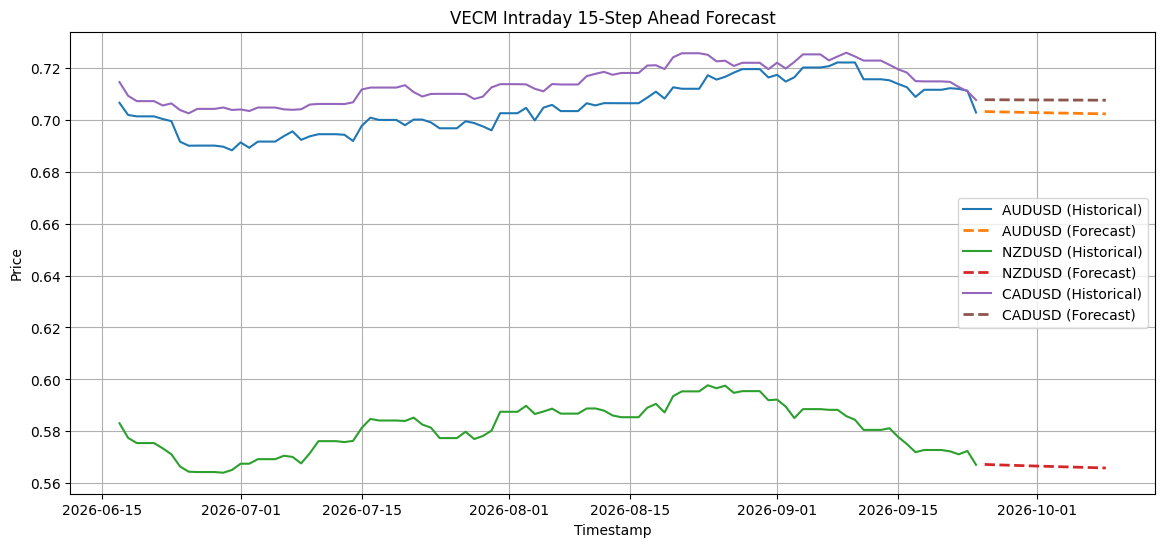

In [8]:
# Generate N-step ahead forecast (e.g., next 15 minutes / periods)
forecast_steps = 15
forecast_arr = vecm_res.predict(steps=forecast_steps)

# Construct forecast DataFrame
last_timestamp = data.index[-1]
freq = pd.infer_freq(data.index) or "1min"
future_index = pd.date_range(
    start=last_timestamp, periods=forecast_steps + 1, freq=freq
)[1:]

forecast_df = pd.DataFrame(
    forecast_arr, index=future_index, columns=data.columns
)

# Plot historical + forecasted values
plt.figure(figsize=(14, 6))
for col in data.columns:
    hist = data[col].iloc[-100:]  # Plot last 100 intraday bars
    plt.plot(hist.index, hist.values, label=f"{col} (Historical)")
    plt.plot(
        forecast_df.index,
        forecast_df[col].values,
        "--",
        linewidth=2,
        label=f"{col} (Forecast)",
    )

plt.title(f"VECM Intraday {forecast_steps}-Step Ahead Forecast")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()